<div style="
background-color:#EAEAEA;
padding:20px;
border-left:5px solid #6C757D;
border-radius:6px;">

<table style="width:100%; border:none;">
<tr style="border:none;">

<td style="border:none; vertical-align:top;">

<h1 style="font-size:32px; margin-top:0;">
Master's Thesis
</h1>

<hr style="margin:16px 0 22px 0;">

<p style="font-size:22px; line-height:1.5; margin:0;">
<strong>Master's Degree in Advanced Physics</strong> - 
<strong>Universitat de Val?ncia</strong>
</p>

<p style="font-size:17px; margin-top:28px; margin-bottom:6px;">
This notebook is part of the <strong>Master's Thesis (MSc Dissertation)</strong>:
</p>

<div style="
font-size:25px;
font-weight:700;
line-height:1.3;
margin-top:14px;
margin-bottom:26px;">
Fast Simulation of Neutrino Oscillations in Matter
</div>

<p style="font-size:14px; line-height:1.55;">
<strong>Author</strong><br>
Juan Ramon Diaz Santos - 
<a href="mailto:diazjuan@alumni.uv.es">diazjuan@alumni.uv.es</a>
</p>

<p style="font-size:14px; line-height:1.55;">
<strong>Supervisors</strong><br>
Roberto Ruiz de Austri Bazan ?
<a href="mailto:rruiz@ific.uv.es">rruiz@ific.uv.es</a><br>
Michele Lucente ?
<a href="mailto:michele.lucente@unibo.it">michele.lucente@unibo.it</a>
</p>

<p style="font-size:14px; line-height:1.55; margin-bottom:0;">
<strong>Date</strong><br>
September 2026
</p>

</td>

<td style="
border:none;
width:230px;
padding-left:25px;
text-align:right;
vertical-align:top;">

<img src="../../logo_uv.png"
     alt="Universitat de Val?ncia"
     style="width:200px; margin-top:5px;">

</td>

</tr>
</table>

</div>

# Earth Diagnostic 1 - Electron Density and Trajectory Geometry
---

This notebook starts the Earth diagnostic series. It isolates the electron-density
model used by Earth matter-regeneration propagation, `EarthProfile`
(`tpeanuts.medium.earth.profile`), and the trajectory geometry utilities that turn a
detector depth and nadir angle into a sampled path, `tpeanuts.medium.earth.geometry`.

The notebook is intentionally diagnostic rather than a pytest suite. The automated
sanity checks live in `tpeanuts.medium.earth.test.test1_density` (density) and
`tpeanuts.medium.earth.test.test2_geometry` (geometry); here we keep the plots and
physical interpretation. A deeper geophysical comparison between density models
(even-power vs PREM, layer anatomy, path-length budgets) already lives in
`notebooks/analysis/earth/Earth1_Geometry_and_Density.ipynb`; this notebook stays
focused on the two modules' own APIs and on the exact scenarios exercised by the
pytest modules.

---

## Table of Contents

| # | Section |
|---|---------|
| [0](#0.-Theory-Background) | **Theory Background**: layered even-power density, chord geometry, shell crossing, detector depth |
| [1](#1.-Libraries) | **Libraries** |
| [2](#2.-Paths-and-Configuration) | **Paths and Configuration** |
| [3](#3.-Radial-Density-Profile) | **Radial Density Profile**: `density_x_eta` at nadir incidence |
| [4](#4.-Earth-Trajectory-Geometry) | **Earth Trajectory Geometry**: Case-A chord diagram and shell crossings |
| [5](#5.-Density-Along-a-Trajectory) | **Density Along a Trajectory**: `density_x_eta` for several nadir angles |
| [6](#6.-Synthetic-Two-Shell-Sanity-Check) | **Synthetic Two-Shell Sanity Check**: visual cross-check of the pytest closed-form values |
| [7](#7.-Detector-Depth-and-eta-prime-Geometry) | **Detector Depth and $\eta'$ Geometry**: `detector_radius_fraction`, `eta_prime_from_eta`, `detector_x_coordinate` |
| [8](#8.-Case-B-Chord-Length-and-Region-Classification) | **Case-B Chord Length and Region Classification**: `chord_length_case_b`, `classify_eta_regions` |
| [9](#9.-Full-Trajectory-Construction) | **Full Trajectory Construction**: `build_earth_trajectory` end to end |
| [10](#10.-Summary) | **Summary** |


## 0. Theory Background

### 0.1 Layered Even-Power Density Model

`EarthProfile` stores Earth's electron density as a set of shells with strictly
increasing radii $r_1<r_2<\dots<r_n\le 1$ (in units of $R_\oplus$). Within shell
$j$, the electron density is an even-power polynomial in the chord coordinate $x$,

$$
n_e^{(j)}(x) = \alpha_j + \beta_j\,x^2 + \gamma_j\,x^4 + \dots,
$$

so that $n_e$ only depends on $x^2$: the model is symmetric about the point of
closest approach. `EvenPowerProfileLayered` stores these coefficients per shell;
`EarthProfile` adds the shell radii and the trajectory geometry described below.

---

### 0.2 Chord Geometry

A detector at the surface observes a neutrino arriving with nadir angle $\eta$
(the angle between the local vertical and the incoming direction). The
Earth-crossing chord is parametrized by a coordinate $x$ measured from the point
of closest approach to the centre, related to the radial coordinate $r$ by

$$
r^2 = x^2 + \sin^2\eta .
$$

At $\eta=0$ (straight down) the chord passes through the centre and $x=r$. As
$\eta\to\pi/2$ (grazing incidence) the chord's closest approach to the centre,
$\sin\eta$, approaches the surface and the path inside the Earth shrinks to zero.
The chord spans $x\in[-\cos\eta,\cos\eta]$; outside that range the trajectory has
left the Earth and the density is zero.

---

### 0.3 Shell Crossing

Shell $j$ is crossed by a trajectory with nadir angle $\eta$ if and only if its
radius exceeds the chord's distance of closest approach to the centre,

$$
\text{crossed}_j(\eta) = \bigl[\,r_j > \sin\eta\,\bigr].
$$

The critical angle at which shell $j$ stops being crossed is
$\eta_c(r_j)=\arcsin(r_j)$: increasing $\eta$ removes the smallest-radius (deepest)
shells first, since $\sin\eta$ has to exceed $r_j$. At $\eta=\pi/2$, $\sin\eta=1$
and, since every $r_j\le1$, no shell is crossed. The chord coordinate where shell
$j$'s boundary is reached is $x_j(\eta)=\sqrt{\max(r_j^2-\sin^2\eta,\,0)}$.

`EarthProfile.shells_x(eta)` returns exactly these two quantities
(`xj_all`, `crossed`) plus a `searchsorted` index `idx0`.

---

### 0.4 Pointwise Density Evaluation

`density_x_eta(x, eta)` evaluates $n_e$ at coordinate $x$ along the trajectory with
nadir angle $\eta$. It:

1. Builds the trajectory-shifted profile (the layered polynomial rewritten in the
   $x$ coordinate via the binomial shift $r^2=x^2+\sin^2\eta$).
2. Uses `searchsorted` over the crossed shells' boundary positions to pick the
   layer that contains $|x|$ (uncrossed shells are pushed to $-\infty$ so they are
   never selected).
3. Sets the density to zero wherever $|x|>\cos\eta$ (the trajectory has exited the
   Earth).

Because only $|x|$ is used, $n_e(x,\eta)=n_e(-x,\eta)$: the density is even about
the point of closest approach, as physically expected for a spherically symmetric
Earth.

---

### 0.5 Detector Depth and the Surface-Equivalent Angle

A detector buried at depth $d$ sits at dimensionless radius

$$
r_d = 1 - \frac{d}{R_\oplus} \qquad \text{('detector-radius-fraction')}.
$$

A chord that reaches this detector with nadir angle $\eta$ corresponds, by the
same similar-triangles argument used for $r^2=x^2+\sin^2\eta$, to a full
surface-to-surface chord with the smaller "surface-equivalent" angle

$$
\eta' = \arcsin\!\bigl(r_d\sin\eta\bigr) \qquad \text{(`eta-prime-from-eta`)}.
$$

At the surface ($r_d=1$), $\eta'=\eta$ identically; for $r_d<1$, $\eta'\le\eta$
pointwise. `shells_x`/`density_x_eta` are evaluated at $\eta'$, not $\eta$, so that
shell-crossing geometry is always expressed relative to the true Earth surface.

---

### 0.6 Detector Coordinate and the Case-B Path Length

The detector's own position along the chord is

$$
x_d = r_d\cos\eta \qquad \text{(`detector-x-coordinate`)}.
$$

For $\eta<\pi/2$ ("Case A"), the trajectory arrives from below the local horizon
and crosses Earth shells on its way to the detector: the sampled path runs from the
farthest crossed shell boundary up to $x_d$. For $\eta\ge\pi/2$ ("Case B"), the
trajectory arrives from above the local horizon and, if the detector has any depth
at all, only clips the thin shallow region between the true surface and the
detector. Its length is

$$
\Delta x = r_d\cos\eta + \sqrt{1-r_d^2\sin^2\eta} \qquad \text{(`chord-length-case-b`)},
$$

which is exactly $0$ at $\eta=\pi/2$, $r_d=1$: a surface detector sees no matter at
all along a perfectly grazing trajectory.

---

### 0.7 Region Classification

`classify_eta_regions(eta, depth_m)` partitions the nadir-angle domain
$\eta\in[0,\pi]$ into three disjoint masks:

- **above** ($d=0$ only): $\eta\ge\pi/2$ at the surface is pure vacuum, no Earth
  matter is crossed at all.
- **Case A**: $\eta<\pi/2$, the shell-crossing regime of Section 0.3.
- **Case B**: $\eta\ge\pi/2$ **and** $d>0$, the shallow near-surface regime of
  Section 0.6. At the surface this mask is empty, since Case B degenerates into the
  "above" vacuum mask.

---

### 0.8 Assembling the Trajectory

`build_earth_trajectory` combines all of the above into a single sampled path fed
to the medium-independent numerical evolutor: for Case A it samples from
$x_1=-\max_j x_j(\eta')$ (the farthest crossed shell boundary) to $x_2=x_d$; for
Case B it samples from $x_1=0$ to $x_2=\Delta x$. Either way the result is an
`(N+1)`-point boundary grid `x`, per-segment dimensionless lengths `dx_evolution`,
and per-segment sample points `sample_x` (midpoint by default) at which the
electron density is evaluated.

---

### References

- A. M. Dziewonski and D. L. Anderson, "Preliminary reference Earth model",
  *Physics of the Earth and Planetary Interiors* **25**, 297 (1981).
- L. Wolfenstein, "Neutrino oscillations in matter", *Physical Review D* **17**,
  2369 (1978).
- S. P. Mikheyev and A. Yu. Smirnov, "Resonant amplification of neutrino
  oscillations in matter", *Il Nuovo Cimento C* **9**, 17 (1986).


## 1. Libraries

In [1]:
import math

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches

import tpeanuts.util.constant as constant
from tpeanuts.medium.earth.geometry import (
    build_earth_trajectory,
    chord_length_case_b,
    classify_eta_regions,
    detector_radius_fraction,
    detector_x_coordinate,
    eta_prime_from_eta,
)
from tpeanuts.medium.earth.profile import EarthParameters, EarthProfile
from tpeanuts.notebooks.notebookConfig import load_notebook_config
from tpeanuts.notebooks.notebooks_helper import save_and_show, to_numpy
from tpeanuts.util.context import RuntimeContext

print(f"Torch {torch.__version__}")

Torch 2.3.1


## 2. Paths and Configuration

### 2.1 Paths

`load_notebook_config()` resolves the repository root, applies the shared plotting
style, and provides the common output root. The output directory is built from the
notebook path relative to `notebooks/`, excluding the notebook filename:
`diagnostic/earth`.

**Expected results:** the printed paths should point to the local TPeanuts
repository and to an output directory ending in `diagnostic/earth`, and the printed
`EarthProfile` summary should report 5 shells spanning `[~0.19, 1.00] R_E`.

In [2]:
config = load_notebook_config()
ctx = RuntimeContext.resolve(config.device, config.dtype)
OUTPUT_DIR = config.output_dir("diagnostic", "earth")

EARTH_DENSITY_CSV = config.earth_density_file

earth_profile = EarthProfile(
    params=EarthParameters(
        profile_perturbative_name="even_power",
        profile_perturbative_kwargs={"density_file": str(EARTH_DENSITY_CSV)},
    ),
    context=ctx,
)

print(f"Package dir       : {config.package_dir}")
print(f"Output root       : {config.output_root}")
print(f"Output dir        : {OUTPUT_DIR}")
print(f"Earth density CSV : {EARTH_DENSITY_CSV}")
print(f"Device            : {ctx.device}   dtype: {ctx.dtype}")
print(earth_profile)

Package dir       : G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts
Output root       : v:\output
Output dir        : v:\output\diagnostic\earth
Earth density CSV : G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts\data\density\earth_density.csv
Device            : cpu   dtype: torch.float64
EarthProfile | model=even_power | n_shells=5 | r=[0.1920, 1.0000] R_E (6371 km scale) | depth=0 m | method=analytical | cpu / torch.float64


### 2.2 Configuration

| Parameter | Value | Description |
|-----------|-------|-------------|
| $r$ grid | $0.001$ to $1.0$ $R_\oplus$, 600 pts | Radial sampling for the nadir-incidence profile |
| $\eta$ scan | $0$ to $\pi/2-10^{-3}$, 400 pts | Nadir-angle sweep for the shell-crossing diagnostics |
| Named $\eta$ | $0°,30°,60°,80°,89°$ | Representative trajectories for the density-along-chord plot |
| Detector depths | $0, 1000, 3000, 10000$ m | Representative depths for the $\eta'$/case-B geometry plots |

In [3]:
R_GRID = torch.linspace(0.001, 1.0, 600, device=ctx.device, dtype=ctx.dtype)
ETA_SCAN = torch.linspace(0.0, math.pi / 2 - 1.0e-3, 400, device=ctx.device, dtype=ctx.dtype)
NAMED_ETAS_DEG = [0.0, 30.0, 60.0, 80.0, 89.0]
DEPTHS_M = [0.0, 1000.0, 3000.0, 10000.0]

print(f"r grid   : {float(R_GRID[0]):.3f} -- {float(R_GRID[-1]):.3f} R_E ({R_GRID.numel()} pts)")
print(f"eta scan : {float(ETA_SCAN[0]):.4f} -- {float(ETA_SCAN[-1]):.4f} rad ({ETA_SCAN.numel()} pts)")
print(f"named eta: {NAMED_ETAS_DEG} deg")
print(f"depths   : {DEPTHS_M} m")

r grid   : 0.001 -- 1.000 R_E (600 pts)
eta scan : 0.0000 -- 1.5698 rad (400 pts)
named eta: [0.0, 30.0, 60.0, 80.0, 89.0] deg
depths   : [0.0, 1000.0, 3000.0, 10000.0] m


### 2.3 Helpers

No notebook-specific helper functions are required. The notebook uses `to_numpy`
and `save_and_show` from `tpeanuts.notebooks.notebooks_helper`.

## 3. Radial Density Profile

At $\eta=0$ the chord coordinate equals the radial coordinate, $x=r$, so
`density_x_eta(r, 0)` directly returns the radial profile $n_e(r)$.

**Expected results:** a piecewise even-power curve, positive everywhere, with
visible jumps at each shell boundary $r_j$; the density should be largest at the
centre and decrease toward the surface.

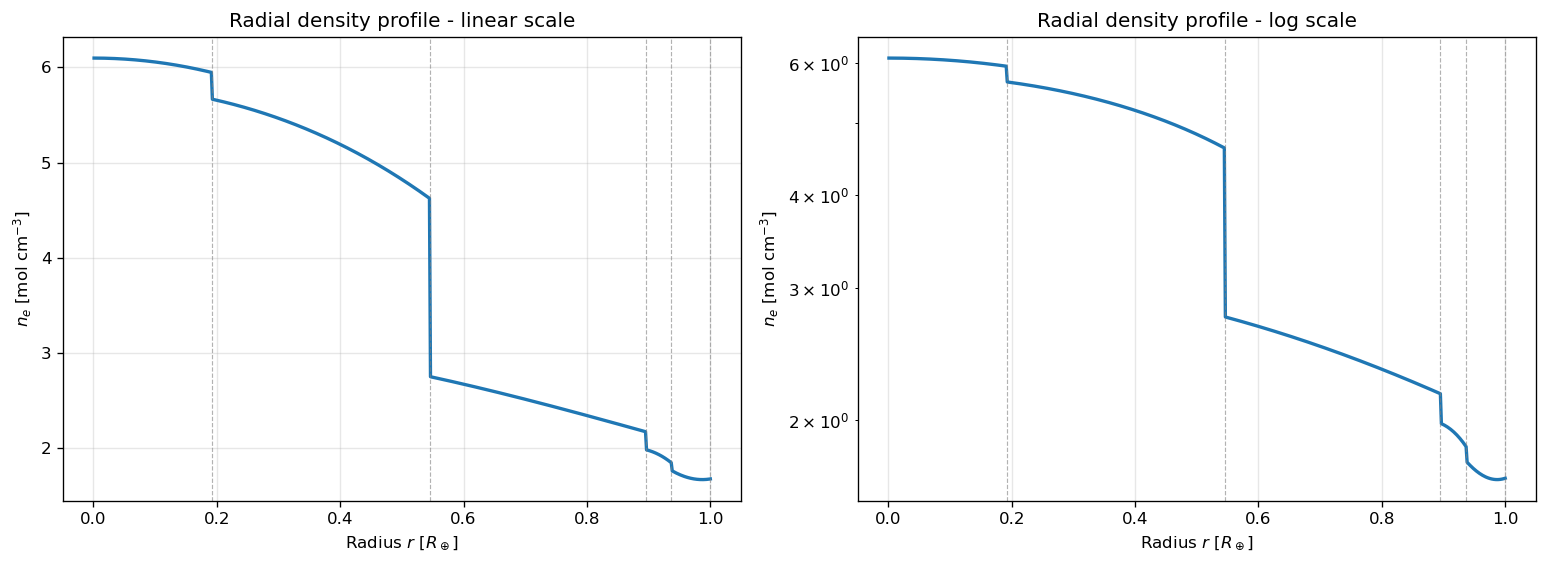

v:\output\diagnostic\earth\diagnostic1_fig3_radial_density.png
Shell radii r_j [R_E] : [0.192 0.546 0.895 0.937 1.   ]
Centre density n_e(0) : 6.0990 mol/cm^3
Surface density n_e(1): 1.6700 mol/cm^3


In [4]:
eta0 = torch.zeros((), device=ctx.device, dtype=ctx.dtype)
ne_r = earth_profile.density_x_eta(R_GRID, eta0)

r_np = to_numpy(R_GRID)
ne_np = to_numpy(ne_r)
rj_np = to_numpy(earth_profile.rj)

fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.8))
for ax, yscale in zip(axes, ["linear", "log"]):
    ax.plot(r_np, ne_np, lw=2.0, color="#1f77b4")
    for rj in rj_np:
        ax.axvline(rj, color="gray", ls="--", lw=0.7, alpha=0.6)
    ax.set_xlabel(r"Radius $r$ [$R_\oplus$]")
    ax.set_ylabel(r"$n_e$ [mol cm$^{-3}$]")
    ax.set_yscale(yscale)
axes[0].set_title("Radial density profile - linear scale")
axes[1].set_title("Radial density profile - log scale")

fig.tight_layout()
save_and_show("diagnostic1_fig3_radial_density.png", fig, output_dir=OUTPUT_DIR, show_plots=config.show_plots)

print(f"Shell radii r_j [R_E] : {rj_np}")
print(f"Centre density n_e(0) : {float(ne_r[0]):.4f} mol/cm^3")
print(f"Surface density n_e(1): {float(ne_r[-1]):.4f} mol/cm^3")

## 4. Earth Trajectory Geometry

### 4.1 Case-A Chord and Detector Geometry

For Case A ($0\leq\eta<\pi/2$), the neutrino enters at the far surface point
$x_s<0$, crosses the point of closest approach $x=0$, and reaches the buried
detector at $x_d>0$. The chord coordinate satisfies $r^2=b^2+x^2$, while
$r_d=(R_\oplus-d)/R_\oplus$ and $b=r_d\sin\eta$.

**Expected results:** the detector lies on the vertical radial axis below the
surface; $OB$ is perpendicular to the chord; the signed ordering along the
propagation path is $x_s<0< x_d$; and $\eta$ and $\eta'$ are attached to the
detector and entry-point vertices respectively.


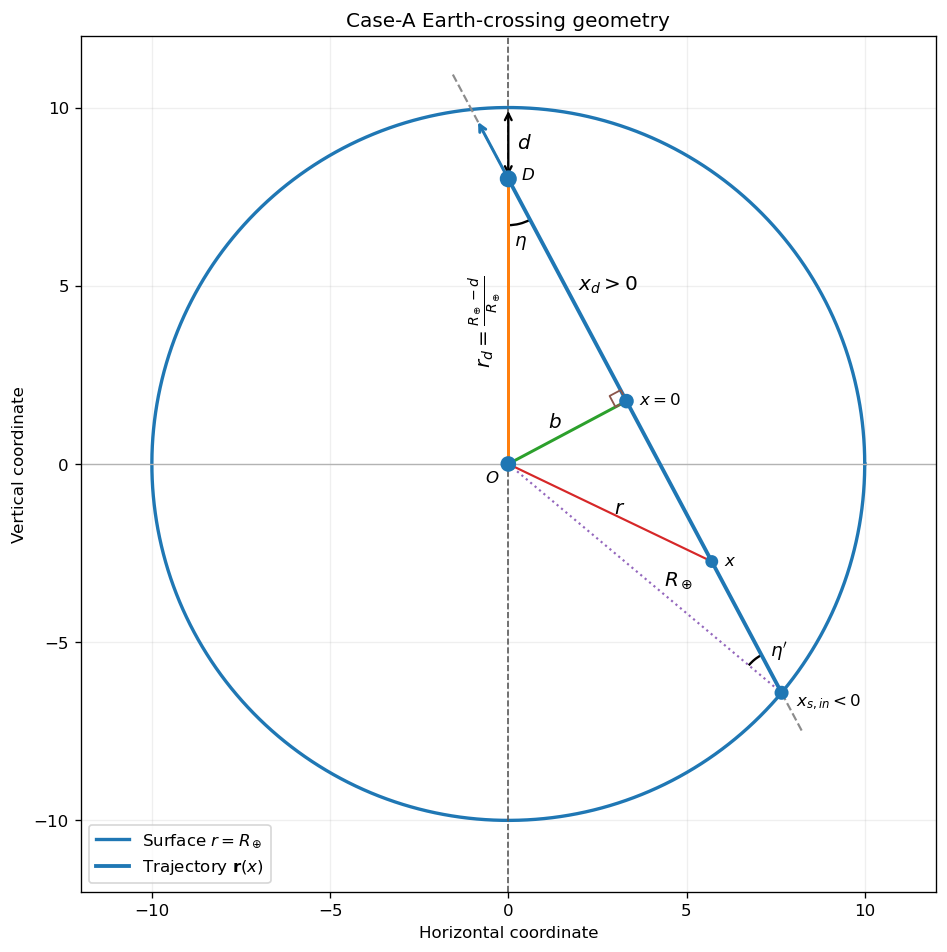

v:\output\diagnostic\earth\diagnostic1_fig4_1_case_a_geometry.png


In [18]:
R, d, eta = 10.0, 2.0, np.deg2rad(28.0)
O, D = np.zeros(2), np.array([0.0, R - d])
v = np.array([np.sin(eta), -np.cos(eta)])          # D -> entry
x_d = -D @ v; B = D + x_d * v; u = -v             # x grows B -> D
roots = np.roots([1.0, 2.0 * (B @ u), B @ B - R**2])
x_s, x_out = float(np.min(roots)), float(np.max(roots))
P_s, P_out, Q = B + x_s * u, B + x_out * u, B + 0.55 * x_s * u
line = np.linspace(x_s - 1.2, x_out + 1.2, 300)
chord = B[:, None] + u[:, None] * line
ang = lambda z: np.degrees(np.arctan2(z[1], z[0]))

fig, ax = plt.subplots(figsize=(8, 10))
th = np.linspace(0, 2*np.pi, 800)
ax.plot(R*np.cos(th), R*np.sin(th), lw=2, label=r"Surface $r=R_\oplus$")
ax.axvline(0, color="0.35", ls="--", lw=1)
ax.axhline(0, color="0.7", lw=.8)
ax.plot(chord[0], chord[1], lw=1.3, color="0.55", ls="--")
ax.plot([P_s[0], D[0]], [P_s[1], D[1]], lw=2.3, color="C0", label=r"Trajectory $\mathbf{r}(x)$")
ax.annotate("", D, D-1.9*v, arrowprops=dict(arrowstyle="<-", color="C0", lw=1.8))
ax.plot([O[0], D[0]], [O[1], D[1]], lw=1.8)
ax.plot([O[0], B[0]], [O[1], B[1]], lw=1.8)
ax.plot([O[0], Q[0]], [O[1], Q[1]], lw=1.3)
ax.plot([O[0], P_s[0]], [O[1], P_s[1]], ls=":", lw=1.3)
ax.scatter(*np.array([O, D, B, Q, P_s]).T, s=[70, 85, 60, 45, 55], zorder=5)
for P, text, off in [(O,"$O$",(-.65,-.5)),(D,"$D$",(.35,-.02)),(B,"$x=0$",(.35,-.1)),
                     (Q,"$x$",(.35,-.1)),(P_s,"$x_{s,in}<0$",(.4,-.35))]:
    ax.text(*(P+off), text, fontsize=10)
ax.text(*(.5*(O+B)+[-.55,.15]), "$b$", fontsize=12) 
ax.text(*(.5*(O+Q)+[.1,-.01]), "$r$", fontsize=12)
ax.text(-1.15, D[1]/2, r"$r_d=\frac{R_\oplus-d}{R_\oplus}$", rotation=90, va="center", fontsize=12)
ax.text(*(.55*P_s+[.15,.15]), "$R_\oplus$", fontsize=12)
ax.text(*(.5*(B+D)+[.3,0]), "$x_d>0$", fontsize=12)
ax.annotate("", (0,R), D, arrowprops=dict(arrowstyle="<->", lw=1.4))
ax.text(.25,(R+D[1])/2,"$d$",va="center",fontsize=12)
n=(O-B)/np.linalg.norm(O-B); s=.35; sq=np.array([B,B+s*u,B+s*u+s*n,B+s*n,B])
ax.plot(sq[:,0],sq[:,1],lw=1.1)
a0,a1=sorted([ang(O-D),ang(P_s-D)])
ax.add_patch(mpatches.Arc(D,2.6,2.6,theta1=a0,theta2=a1,lw=1.4))
ax.text(*(D+1.55*np.array([.1,-1.2])),r"$\eta$",fontsize=11)
a0,a1=sorted([ang(O-P_s),ang(D-P_s)])
ax.add_patch(mpatches.Arc(P_s,2.4,2.4,theta1=a0,theta2=a1,lw=1.4))
ax.text(*(P_s+1.35*np.array([-.25,.75])),r"$\eta'$",fontsize=11)
ax.set(xlim=(-R-2,R+2),ylim=(-R-2,R+2),xlabel="Horizontal coordinate",ylabel="Vertical coordinate",title="Case-A Earth-crossing geometry")
ax.set_aspect("equal")
ax.grid(alpha=.2); ax.legend(loc="lower left"); fig.tight_layout()
save_and_show("diagnostic1_fig4_1_case_a_geometry.png", fig, output_dir=OUTPUT_DIR, show_plots=config.show_plots)


### 4.2 Shell Crossings versus Nadir Angle

`shells_x(eta)` returns, for every shell, whether it is crossed by a trajectory
with nadir angle $\eta$ and the chord coordinate $x_j(\eta)$ of its boundary.
Increasing $\eta$ removes the smallest-radius (deepest) shells first; at
$\eta=\pi/2$ no shell is crossed.

**Expected results:** the crossing heatmap should switch off shell by shell, from
the innermost outward, as $\eta$ grows; each shell's critical angle
$\eta_c=\arcsin(r_j)$ should mark exactly where its $x_j(\eta)$ curve reaches
zero.

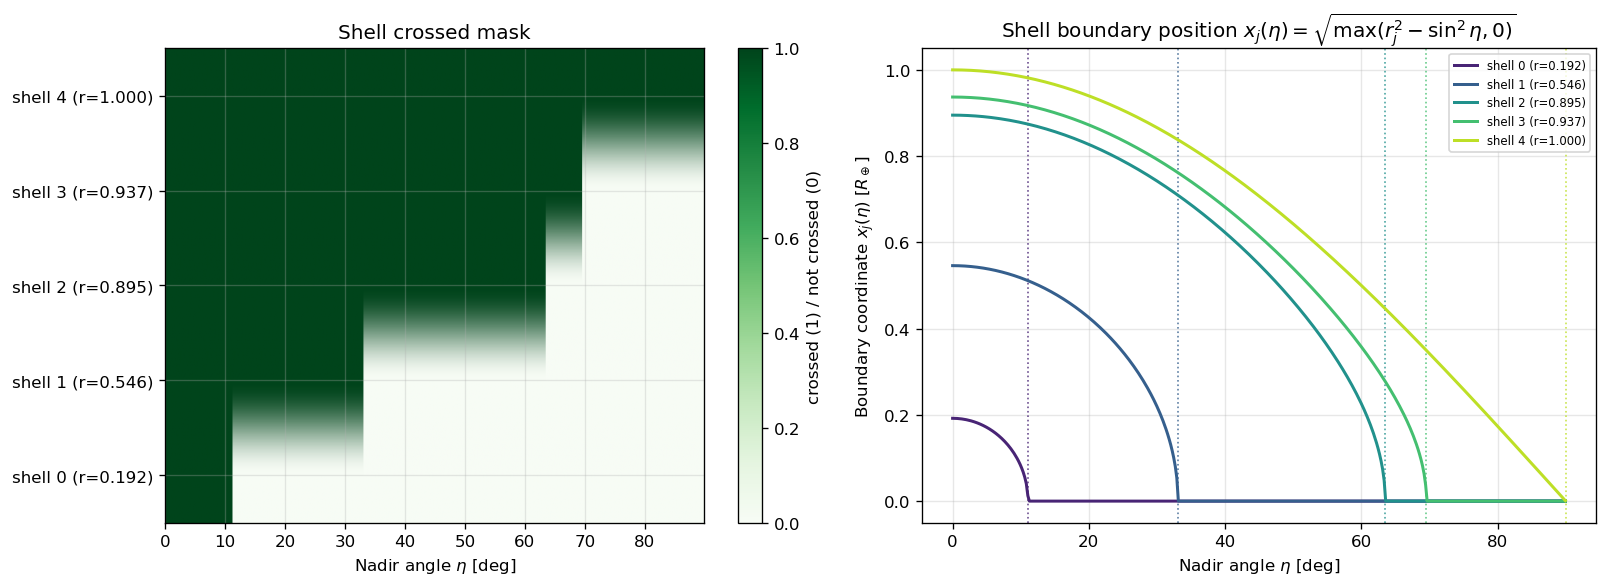

v:\output\diagnostic\earth\diagnostic1_fig4_2_shell_crossings.png
shell |  r_j [R_E] |  eta_c [deg]
    0 |     0.1920 |      11.0695
    1 |     0.5460 |      33.0930
    2 |     0.8950 |      63.5084
    3 |     0.9370 |      69.5537
    4 |     1.0000 |      90.0000


In [6]:
xj_all, crossed, idx0 = earth_profile.shells_x(ETA_SCAN)

eta_deg = np.degrees(to_numpy(ETA_SCAN))
xj_np = to_numpy(xj_all)
crossed_np = to_numpy(crossed).astype(float)
n_shells = rj_np.shape[0]
eta_c_deg = np.degrees(np.arcsin(np.clip(rj_np, -1.0, 1.0)))

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.0))

im = axes[0].imshow(
    crossed_np.T,
    aspect="auto",
    origin="lower",
    extent=[eta_deg[0], eta_deg[-1], -0.5, n_shells - 0.5],
    cmap="Greens",
)
axes[0].set_yticks(range(n_shells))
axes[0].set_yticklabels([f"shell {j} (r={rj_np[j]:.3f})" for j in range(n_shells)])
axes[0].set_xlabel(r"Nadir angle $\eta$ [deg]")
axes[0].set_title("Shell crossed mask")
fig.colorbar(im, ax=axes[0], label="crossed (1) / not crossed (0)")

colors = plt.cm.viridis(np.linspace(0.1, 0.9, n_shells))
for j in range(n_shells):
    axes[1].plot(eta_deg, xj_np[:, j], color=colors[j], lw=1.8, label=f"shell {j} (r={rj_np[j]:.3f})")
    axes[1].axvline(eta_c_deg[j], color=colors[j], ls=":", lw=1.0, alpha=0.8)
axes[1].set_xlabel(r"Nadir angle $\eta$ [deg]")
axes[1].set_ylabel(r"Boundary coordinate $x_j(\eta)$ [$R_\oplus$]")
axes[1].set_title(r"Shell boundary position $x_j(\eta)=\sqrt{\max(r_j^2-\sin^2\eta,0)}$")
axes[1].legend(fontsize=7)

fig.tight_layout()
save_and_show("diagnostic1_fig4_2_shell_crossings.png", fig, output_dir=OUTPUT_DIR, show_plots=config.show_plots)

print(f"{'shell':>5} | {'r_j [R_E]':>10} | {'eta_c [deg]':>12}")
for j in range(n_shells):
    print(f"{j:>5} | {rj_np[j]:>10.4f} | {eta_c_deg[j]:>12.4f}")

## 5. Density Along a Trajectory

`density_x_eta(x, eta)` evaluated over $x\in[-\cos\eta,\cos\eta]$ traces the
electron density seen along a single neutrino trajectory. Sampling slightly beyond
that range shows the "outside Earth" zero-clamp; the curve should also be exactly
symmetric about $x=0$.

**Expected results:** each curve is flat/zero beyond $|x|=\cos\eta$, shows shell
jumps inside that range, and is mirror-symmetric about $x=0$; the printed
symmetry error should be at machine precision.

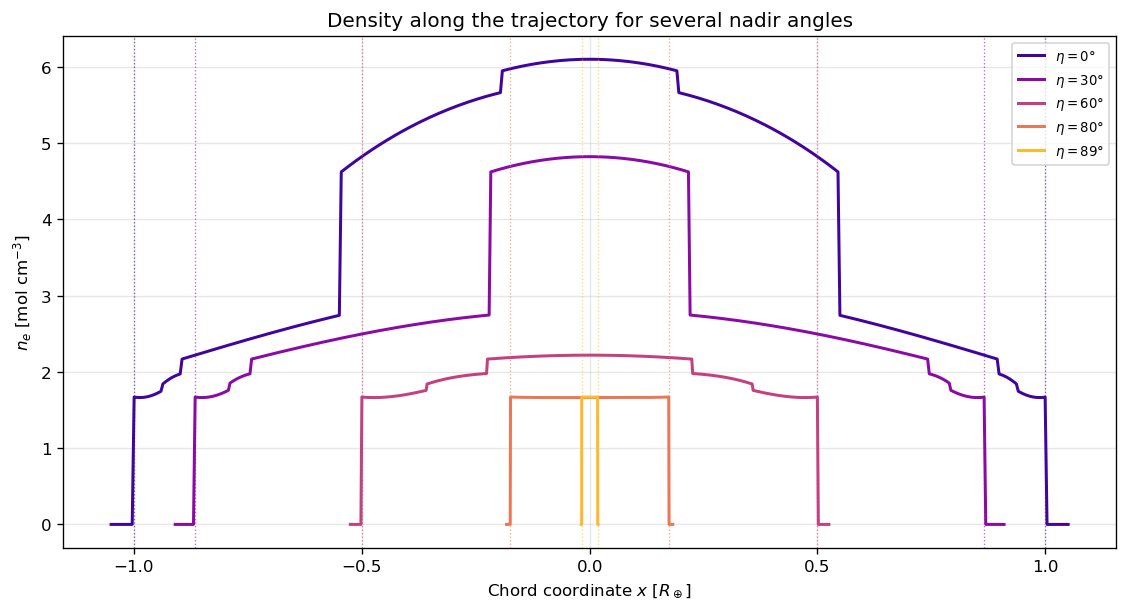

v:\output\diagnostic\earth\diagnostic1_fig5_density_along_trajectory.png
max |n_e(x,eta) - n_e(-x,eta)| over all sampled trajectories: 0.000e+00


In [7]:
fig, ax = plt.subplots(figsize=(9.5, 5.2))
colors = plt.cm.plasma(np.linspace(0.1, 0.85, len(NAMED_ETAS_DEG)))

max_symmetry_err = 0.0
for eta_deg_val, col in zip(NAMED_ETAS_DEG, colors):
    eta_rad = math.radians(eta_deg_val)
    eta_t = torch.tensor(eta_rad, device=ctx.device, dtype=ctx.dtype)
    x_max = math.cos(eta_rad)
    x_traj = torch.linspace(-1.05 * x_max, 1.05 * x_max, 500, device=ctx.device, dtype=ctx.dtype)

    ne_traj = earth_profile.density_x_eta(x_traj, eta_t)
    ne_mirror = earth_profile.density_x_eta(-x_traj, eta_t)
    max_symmetry_err = max(max_symmetry_err, float(torch.max(torch.abs(ne_traj - ne_mirror))))

    ax.plot(to_numpy(x_traj), to_numpy(ne_traj), color=col, lw=1.8, label=rf"$\eta={eta_deg_val:.0f}°$")
    ax.axvline(x_max, color=col, ls=":", lw=0.8, alpha=0.6)
    ax.axvline(-x_max, color=col, ls=":", lw=0.8, alpha=0.6)

ax.set_xlabel(r"Chord coordinate $x$ [$R_\oplus$]")
ax.set_ylabel(r"$n_e$ [mol cm$^{-3}$]")
ax.set_title("Density along the trajectory for several nadir angles")
ax.legend(fontsize=8)

fig.tight_layout()
save_and_show("diagnostic1_fig5_density_along_trajectory.png", fig, output_dir=OUTPUT_DIR, show_plots=config.show_plots)

print(f"max |n_e(x,eta) - n_e(-x,eta)| over all sampled trajectories: {max_symmetry_err:.3e}")

## 6. Synthetic Two-Shell Sanity Check

The pytest module `tpeanuts.medium.earth.test.test1_density` exercises a small
synthetic two-shell profile with closed-form expected values: constant density
$2.0$ for $r<0.5$ and $1.0$ for $0.5<r\le1.0$. This section rebuilds the same
profile and plots it directly against those expected values, giving a visual
cross-check of the numbers asserted in the automated tests.

**Expected results:** the curve should sit exactly on the dashed reference lines
($2.0$ inside $r<0.5$, $1.0$ between $0.5$ and $1.0$, $0$ outside), both at nadir
incidence and at an oblique angle where only the outer shell is crossed.

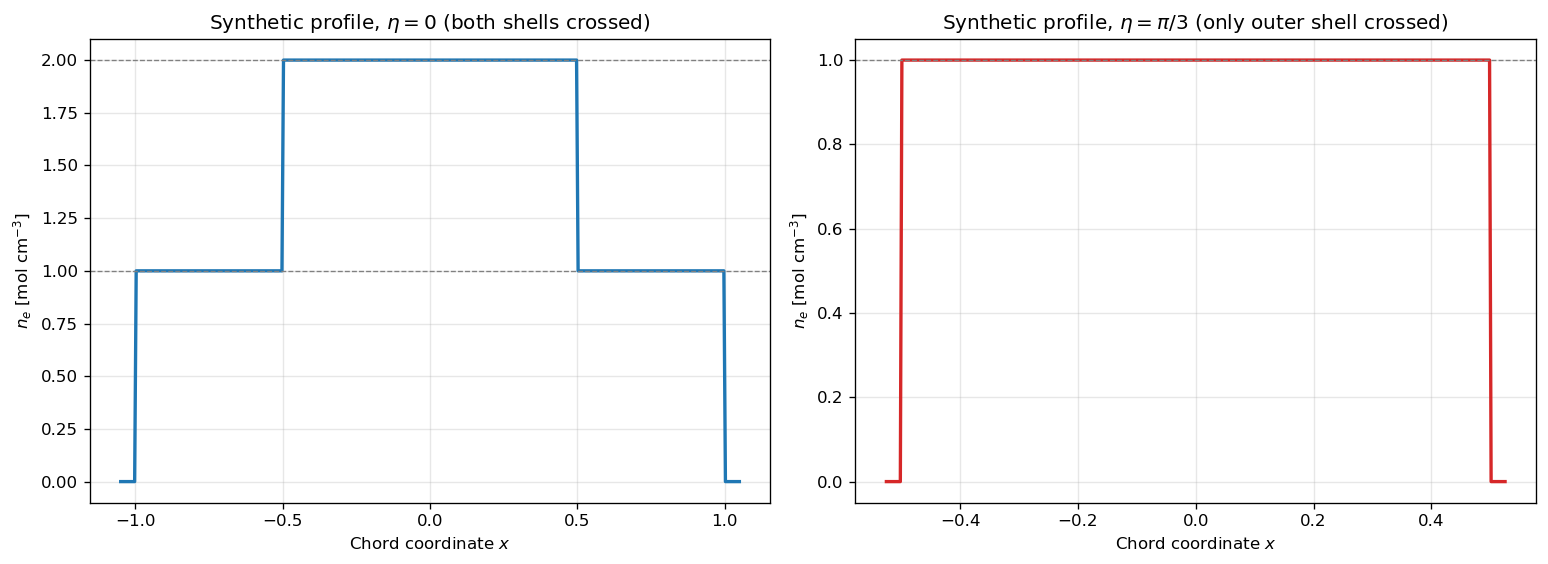

v:\output\diagnostic\earth\diagnostic1_fig6_synthetic_two_shell.png
inner-shell value matches pytest (2.0)  : True
outer-shell value matches pytest (1.0)  : True
oblique closest-approach matches (1.0)  : True


In [8]:
rj_synth = torch.tensor([0.5, 1.0], device=ctx.device, dtype=ctx.dtype)
coefficients_synth = torch.tensor(
    [[2.0, 0.0, 0.0], [1.0, 0.0, 0.0]],
    device=ctx.device,
    dtype=ctx.dtype,
)
synthetic_profile = EarthProfile(
    params=EarthParameters(
        profile_perturbative_name="even_power",
        profile_perturbative_kwargs={"rj": rj_synth, "coefficients": coefficients_synth},
    ),
    context=ctx,
)

eta_pi3 = torch.tensor(math.pi / 3, device=ctx.device, dtype=ctx.dtype)

x_nadir = torch.linspace(-1.05, 1.05, 400, device=ctx.device, dtype=ctx.dtype)
ne_nadir = synthetic_profile.density_x_eta(x_nadir, eta0)

x_oblique_max = math.cos(math.pi / 3)
x_oblique = torch.linspace(-1.05 * x_oblique_max, 1.05 * x_oblique_max, 400, device=ctx.device, dtype=ctx.dtype)
ne_oblique = synthetic_profile.density_x_eta(x_oblique, eta_pi3)

fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.8))
axes[0].plot(to_numpy(x_nadir), to_numpy(ne_nadir), color="#1f77b4", lw=2.0)
axes[0].axhline(2.0, color="gray", ls="--", lw=0.8)
axes[0].axhline(1.0, color="gray", ls="--", lw=0.8)
axes[0].set_title(r"Synthetic profile, $\eta=0$ (both shells crossed)")

axes[1].plot(to_numpy(x_oblique), to_numpy(ne_oblique), color="#d62728", lw=2.0)
axes[1].axhline(1.0, color="gray", ls="--", lw=0.8)
axes[1].set_title(r"Synthetic profile, $\eta=\pi/3$ (only outer shell crossed)")

for ax in axes:
    ax.set_xlabel(r"Chord coordinate $x$")
    ax.set_ylabel(r"$n_e$ [mol cm$^{-3}$]")

fig.tight_layout()
save_and_show("diagnostic1_fig6_synthetic_two_shell.png", fig, output_dir=OUTPUT_DIR, show_plots=config.show_plots)

inner_ok = torch.allclose(
    synthetic_profile.density_x_eta(torch.tensor(0.3, device=ctx.device, dtype=ctx.dtype), eta0),
    torch.tensor(2.0, device=ctx.device, dtype=ctx.dtype),
)
outer_ok = torch.allclose(
    synthetic_profile.density_x_eta(torch.tensor(0.7, device=ctx.device, dtype=ctx.dtype), eta0),
    torch.tensor(1.0, device=ctx.device, dtype=ctx.dtype),
)
oblique_ok = torch.allclose(
    synthetic_profile.density_x_eta(torch.tensor(0.0, device=ctx.device, dtype=ctx.dtype), eta_pi3),
    torch.tensor(1.0, device=ctx.device, dtype=ctx.dtype),
)
print(f"inner-shell value matches pytest (2.0)  : {bool(inner_ok)}")
print(f"outer-shell value matches pytest (1.0)  : {bool(outer_ok)}")
print(f"oblique closest-approach matches (1.0)  : {bool(oblique_ok)}")

## 7. Detector Depth and $\eta'$ Geometry

`eta_prime_from_eta` maps a detector's own nadir angle to the surface-equivalent
angle used for shell-crossing geometry; `detector_x_coordinate` places the detector
itself along the chord. Both depend on the depth only through
$r_d=$ `detector_radius_fraction(depth_m)`.

**Expected results:** all curves collapse onto the identity $\eta'=\eta$ at
$d=0$; deeper detectors bend $\eta'$ increasingly below $\eta$. $x_d(\eta)$ should
cross zero at $\eta=\pi/2$ (for $d=0$) and go negative for $\eta>\pi/2$.

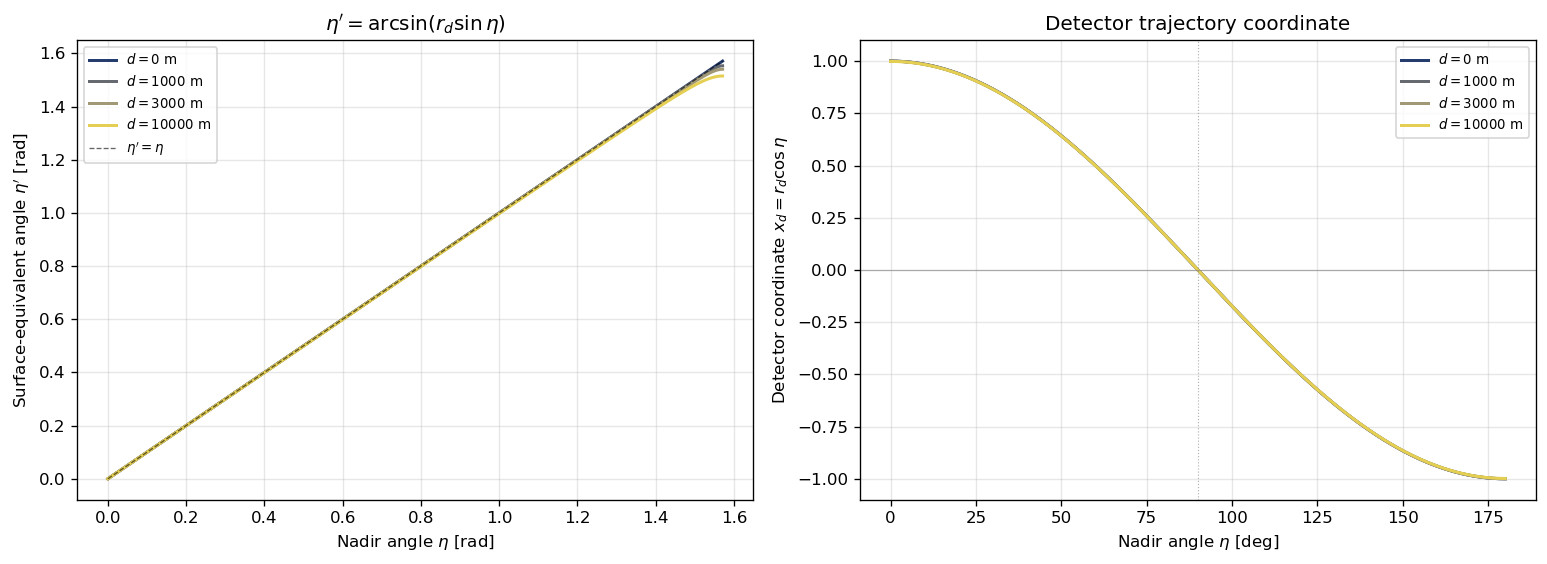

v:\output\diagnostic\earth\diagnostic1_fig7_eta_prime_and_xd.png
 depth [m] |        r_d
         0 |   1.000000
      1000 |   0.999843
      3000 |   0.999529
     10000 |   0.998430


In [9]:
eta_half = torch.linspace(0.0, math.pi / 2.0, 500, device=ctx.device, dtype=ctx.dtype)
eta_full = torch.linspace(0.0, math.pi, 500, device=ctx.device, dtype=ctx.dtype)

fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.8))
depth_colors = plt.cm.cividis(np.linspace(0.15, 0.9, len(DEPTHS_M)))

r_d_table = []
for depth_m, col in zip(DEPTHS_M, depth_colors):
    r_d = detector_radius_fraction(depth_m, device=ctx.device, dtype=ctx.dtype)
    r_d_table.append(float(r_d))

    eta_p = eta_prime_from_eta(eta_half, r_d)
    x_d = detector_x_coordinate(eta_full, r_d)

    axes[0].plot(to_numpy(eta_half), to_numpy(eta_p), color=col, lw=1.8, label=rf"$d={depth_m:.0f}$ m")
    axes[1].plot(np.degrees(to_numpy(eta_full)), to_numpy(x_d), color=col, lw=1.8, label=rf"$d={depth_m:.0f}$ m")

axes[0].plot(to_numpy(eta_half), to_numpy(eta_half), "k--", lw=0.8, alpha=0.6, label=r"$\eta'=\eta$")
axes[0].set_xlabel(r"Nadir angle $\eta$ [rad]")
axes[0].set_ylabel(r"Surface-equivalent angle $\eta'$ [rad]")
axes[0].set_title(r"$\eta'=\arcsin(r_d\sin\eta)$")
axes[0].legend(fontsize=8)

axes[1].axhline(0.0, color="gray", lw=0.7, alpha=0.6)
axes[1].axvline(90.0, color="gray", lw=0.7, ls=":", alpha=0.6)
axes[1].set_xlabel(r"Nadir angle $\eta$ [deg]")
axes[1].set_ylabel(r"Detector coordinate $x_d=r_d\cos\eta$")
axes[1].set_title("Detector trajectory coordinate")
axes[1].legend(fontsize=8)

fig.tight_layout()
save_and_show("diagnostic1_fig7_eta_prime_and_xd.png", fig, output_dir=OUTPUT_DIR, show_plots=config.show_plots)

print(f"{'depth [m]':>10} | {'r_d':>10}")
for depth_m, r_d_val in zip(DEPTHS_M, r_d_table):
    print(f"{depth_m:>10.0f} | {r_d_val:>10.6f}")

## 8. Case-B Chord Length and Region Classification

`chord_length_case_b` gives the shallow near-surface path length for
$\eta\ge\pi/2$. `classify_eta_regions` then partitions the full domain
$\eta\in[0,\pi]$ into the "above" (vacuum-only), Case A (shell-crossing), and
Case B (shallow) regimes described in Section 0.7.

**Expected results:** $\Delta x=0$ at $\eta=\pi/2$ for a surface detector and grows
for deeper detectors; the region strip should show only "above"/Case A at $d=0$
(Case B empty) and only Case A/Case B at $d>0$ (no "above" region).

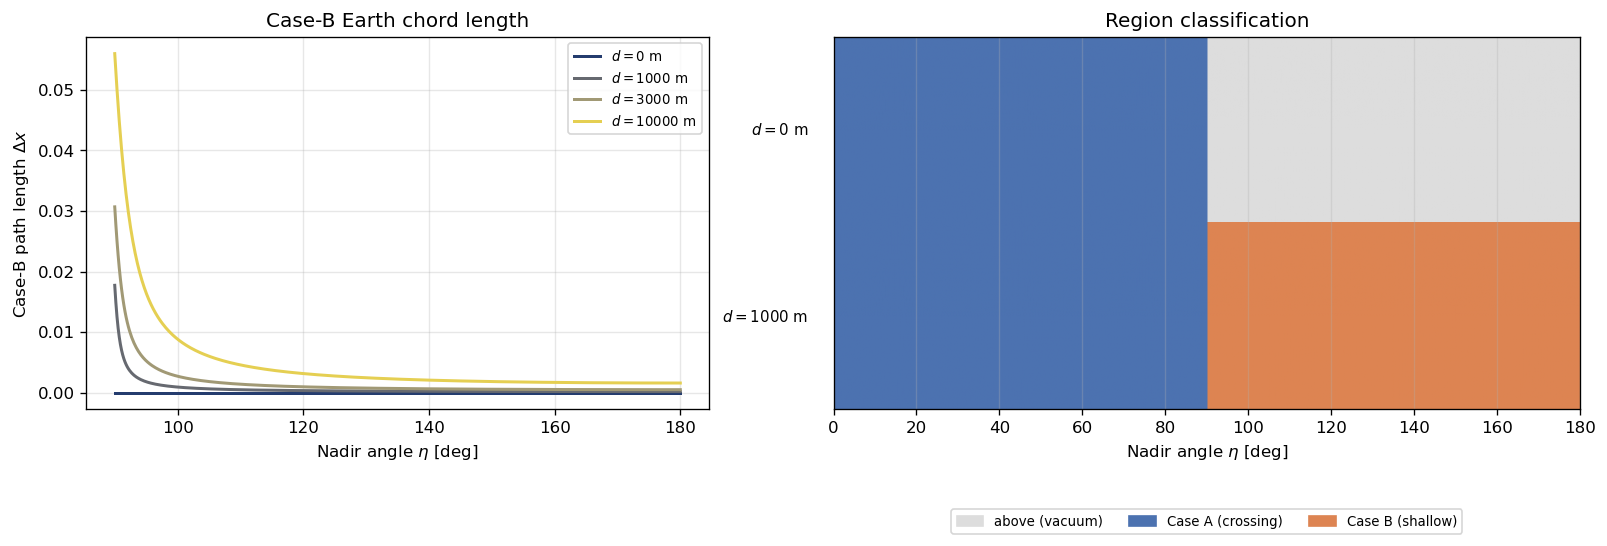

v:\output\diagnostic\earth\diagnostic1_fig8_case_b_and_regions.png
d=     0 m | above: 50.0% | Case A: 50.0% | Case B: 0.0%
d=  1000 m | above: 0.0% | Case A: 50.0% | Case B: 50.0%


In [10]:
eta_caseb = torch.linspace(math.pi / 2.0, math.pi, 500, device=ctx.device, dtype=ctx.dtype)

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8), gridspec_kw={"width_ratios": [1.0, 1.2]})

for depth_m, col in zip(DEPTHS_M, depth_colors):
    r_d = detector_radius_fraction(depth_m, device=ctx.device, dtype=ctx.dtype)
    dx = chord_length_case_b(eta_caseb, r_d)
    axes[0].plot(np.degrees(to_numpy(eta_caseb)), to_numpy(dx), color=col, lw=1.8, label=rf"$d={depth_m:.0f}$ m")

axes[0].set_xlabel(r"Nadir angle $\eta$ [deg]")
axes[0].set_ylabel(r"Case-B path length $\Delta x$")
axes[0].set_title("Case-B Earth chord length")
axes[0].legend(fontsize=8)

region_names = ["above (vacuum)", "Case A (crossing)", "Case B (shallow)"]
region_cmap = mcolors.ListedColormap(["#DDDDDD", "#4C72B0", "#DD8452"])
depths_for_regions = [0.0, 1000.0]

for row, depth_m in enumerate(depths_for_regions):
    above, mask_a, mask_b = classify_eta_regions(eta_full, depth_m=depth_m)
    codes = torch.zeros_like(eta_full)
    codes = torch.where(mask_a, torch.ones_like(codes), codes)
    codes = torch.where(mask_b, 2.0 * torch.ones_like(codes), codes)

    y0, y1 = 1.0 - (row + 1) / len(depths_for_regions), 1.0 - row / len(depths_for_regions)
    axes[1].imshow(
        to_numpy(codes)[None, :],
        aspect="auto",
        origin="lower",
        extent=[0.0, 180.0, y0, y1],
        cmap=region_cmap,
        vmin=0,
        vmax=2,
    )
    axes[1].text(-6.0, 0.5 * (y0 + y1), rf"$d={depth_m:.0f}$ m", ha="right", va="center", fontsize=9)

axes[1].set_xlim(0.0, 180.0)
axes[1].set_ylim(0.0, 1.0)
axes[1].set_yticks([])
axes[1].set_xlabel(r"Nadir angle $\eta$ [deg]")
axes[1].set_title("Region classification")
legend_patches = [mpatches.Patch(color=region_cmap(i), label=region_names[i]) for i in range(3)]
axes[1].legend(handles=legend_patches, fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.25), ncol=3)

fig.tight_layout()
save_and_show("diagnostic1_fig8_case_b_and_regions.png", fig, output_dir=OUTPUT_DIR, show_plots=config.show_plots)

for depth_m in depths_for_regions:
    above, mask_a, mask_b = classify_eta_regions(eta_full, depth_m=depth_m)
    print(f"d={depth_m:>6.0f} m | above: {int(above.sum())/eta_full.numel():.1%} | "
          f"Case A: {int(mask_a.sum())/eta_full.numel():.1%} | Case B: {int(mask_b.sum())/eta_full.numel():.1%}")

## 9. Full Trajectory Construction

`build_earth_trajectory` combines everything above into the sampled path used by
the numerical Earth evolutor. For Case A angles it returns an `"earth_crossing"`
trajectory sampled against the real Earth density profile from Section 2; for
Case B angles it returns a `"local_constant"` trajectory sampled at a single
midpoint density, matching how `medium.earth.probability.earth_probability_state_numerical` uses
this function internally.

**Expected results:** Case A angles report `mode="earth_crossing"` with
`x[-1]=x_d`; Case B angles report `mode="local_constant"` with `x[0]=0` and
`x[-1]=` the Section 8 case-B chord length. The density-vs-sample-point plot should
look like Section 5's trajectory curves for the Case A angle, and be flat for the
Case B angle.

 eta [deg] |            mode |       x[0] |      x[-1] |  n points
      10.0 |  earth_crossing |    -0.9848 |     0.9848 |        61
      45.0 |  earth_crossing |    -0.7071 |     0.7071 |        61
      80.0 |  earth_crossing |    -0.1736 |     0.1736 |        61
     100.0 |  local_constant |     0.0000 |     0.0000 |        61
     150.0 |  local_constant |     0.0000 |    -0.0000 |        61


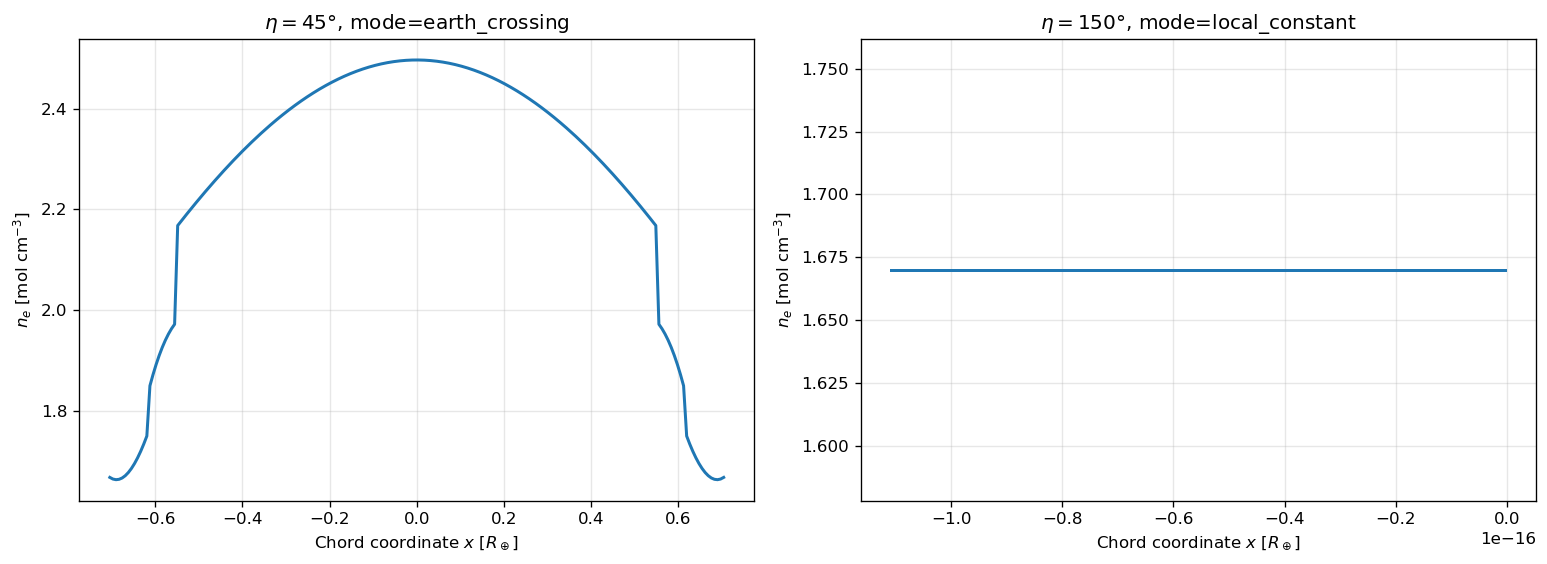

v:\output\diagnostic\earth\diagnostic1_fig9_trajectory_density.png


In [11]:
DEMO_ETAS_DEG = [10.0, 45.0, 80.0, 100.0, 150.0]

print(f"{'eta [deg]':>10} | {'mode':>15} | {'x[0]':>10} | {'x[-1]':>10} | {'n points':>9}")
for eta_deg_val in DEMO_ETAS_DEG:
    eta_t = torch.tensor(math.radians(eta_deg_val), device=ctx.device, dtype=ctx.dtype)
    traj = build_earth_trajectory(
        profile_earth=earth_profile,
        eta=eta_t,
        depth_m=0.0,
        nsteps=60,
        method="midpoint",
        device=ctx.device,
        dtype=ctx.dtype,
        evolution_scale_m=constant.R_E,
    )
    print(f"{eta_deg_val:>10.1f} | {traj.meta['mode']:>15} | {float(traj.x[0]):>10.4f} | "
          f"{float(traj.x[-1]):>10.4f} | {traj.x.numel():>9}")

fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.8))
for ax, eta_deg_val in zip(axes, [45.0, 150.0]):
    eta_t = torch.tensor(math.radians(eta_deg_val), device=ctx.device, dtype=ctx.dtype)
    traj = build_earth_trajectory(
        profile_earth=earth_profile,
        eta=eta_t,
        depth_m=0.0,
        nsteps=200,
        method="midpoint",
        device=ctx.device,
        dtype=ctx.dtype,
        evolution_scale_m=constant.R_E,
    )
    if traj.meta["mode"] == "earth_crossing":
        n_e = earth_profile.call(traj.sample_x, traj.meta["eta_prime"])
    else:
        r_mid = 0.5 * (1.0 + traj.meta["r_d"])
        n_1 = earth_profile.call(r_mid, torch.zeros((), device=ctx.device, dtype=ctx.dtype))
        n_e = torch.ones_like(traj.sample_x) * n_1

    ax.plot(to_numpy(traj.sample_x), to_numpy(n_e), color="#1f77b4", lw=1.8)
    ax.set_xlabel(r"Chord coordinate $x$ [$R_\oplus$]")
    ax.set_ylabel(r"$n_e$ [mol cm$^{-3}$]")
    ax.set_title(rf"$\eta={eta_deg_val:.0f}°$, mode={traj.meta['mode']}")

fig.tight_layout()
save_and_show("diagnostic1_fig9_trajectory_density.png", fig, output_dir=OUTPUT_DIR, show_plots=config.show_plots)

## 10. Summary

In [12]:
print("Summary - Earth Diagnostic 1: Electron Density and Trajectory Geometry")
print("-" * 60)
print(f"Loaded Earth model    : {earth_profile}")
print(f"Number of shells      : {rj_np.shape[0]}")
print(f"Shell radii [R_E]     : {rj_np}")
print(f"Critical angles [deg] : {eta_c_deg}")
print(f"Max trajectory symmetry error: {max_symmetry_err:.3e}")
print(f"Synthetic two-shell sanity check passed: {bool(inner_ok and outer_ok and oblique_ok)}")
print(f"Detector radius fractions r_d: {dict(zip(DEPTHS_M, r_d_table))}")
print()
print("Pytest companions: tpeanuts.medium.earth.test.test1_density, tpeanuts.medium.earth.test.test2_geometry")
print("Deeper geophysical comparison: notebooks/analysis/earth/Earth1_Geometry_and_Density.ipynb")

Summary - Earth Diagnostic 1: Electron Density and Trajectory Geometry
------------------------------------------------------------
Loaded Earth model    : EarthProfile | model=even_power | n_shells=5 | r=[0.1920, 1.0000] R_E (6371 km scale) | depth=0 m | method=analytical | cpu / torch.float64
Number of shells      : 5
Shell radii [R_E]     : [0.192 0.546 0.895 0.937 1.   ]
Critical angles [deg] : [11.069525 33.093027 63.50843  69.553699 90.      ]
Max trajectory symmetry error: 0.000e+00
Synthetic two-shell sanity check passed: True
Detector radius fractions r_d: {0.0: 1.0, 1000.0: 0.9998430387694239, 3000.0: 0.9995291163082719, 10000.0: 0.9984303876942395}

Pytest companions: tpeanuts.medium.earth.test.test1_density, tpeanuts.medium.earth.test.test2_geometry
Deeper geophysical comparison: notebooks/analysis/earth/Earth1_Geometry_and_Density.ipynb
